In [65]:
!ls /mnt/workspace/ChestX-Det-Dataset/

ChestX_Det_test.json   test	      train
ChestX_Det_train.json  test_data.zip  train_data.zip


In [66]:
import pandas as pd
from collections import Counter
from IPython.display import Image
from medvqa.utils.files_utils import load_json

In [67]:
test_data = load_json('/mnt/workspace/ChestX-Det-Dataset/ChestX_Det_test.json')

In [68]:
train_data = load_json('/mnt/workspace/ChestX-Det-Dataset/ChestX_Det_train.json')

In [69]:
len(train_data)

3025

In [70]:
len(test_data)

553

In [76]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.patheffects as PathEffects
import cv2
import os

def visualize_item(
    item, 
    image_dir, 
    figsize=(10, 10), 
    box_color='lime', 
    poly_color='red', 
    text_color='yellow'
):
    """
    Visualize a dataset item with bounding boxes, polygons, and labels.

    Args:
        item (dict): One item from the dataset.
        image_dir (str): Directory containing the images.
        figsize (tuple): Figure size for matplotlib.
        box_color (str): Color for bounding boxes.
        poly_color (str): Color for polygons.
        text_color (str): Color for label text.
    """
    # Load image
    img_path = os.path.join(image_dir, item['file_name'])
    img = cv2.imread(img_path)
    if img is None:
        raise FileNotFoundError(f"Image not found: {img_path}")
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Prepare plot
    fig, ax = plt.subplots(1, 1, figsize=figsize)
    ax.imshow(img)
    ax.axis('off')

    # Draw boxes, polygons, and labels
    for sym, box, poly in zip(item['syms'], item['boxes'], item['polygons']):
        # Draw bounding box
        x1, y1, x2, y2 = box
        rect = patches.Rectangle(
            (x1, y1), x2 - x1, y2 - y1, 
            linewidth=2, edgecolor=box_color, facecolor='none'
        )
        ax.add_patch(rect)

        # Draw polygon
        poly_pts = poly + [poly[0]]  # close the polygon
        poly_x, poly_y = zip(*poly_pts)
        ax.plot(poly_x, poly_y, color=poly_color, linewidth=2)

        # Annotate with label
        label_x, label_y = poly[0]
        txt = ax.text(
            label_x, label_y, sym, color=text_color, fontsize=12, weight='bold',
            bbox=dict(facecolor='black', alpha=0.5, pad=1, edgecolor='none')
        )
        txt.set_path_effects([
            PathEffects.Stroke(linewidth=2, foreground='black'),
            PathEffects.Normal()
        ])

    plt.show()
    
    print(item['syms'])

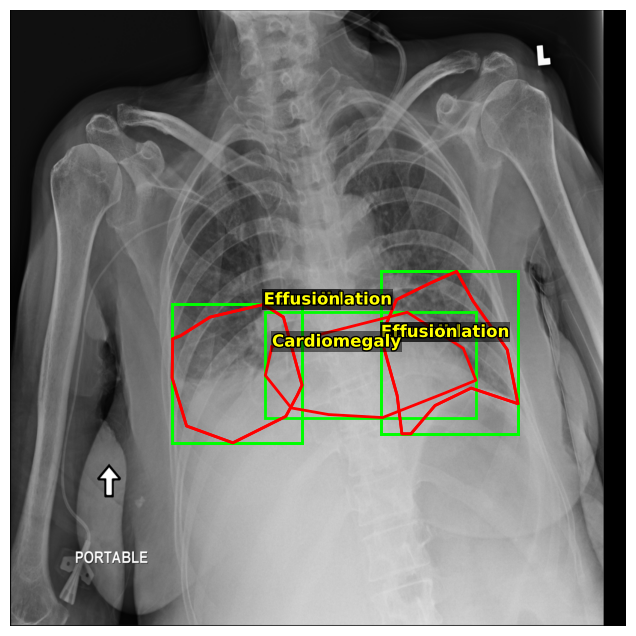

['Consolidation', 'Effusion', 'Consolidation', 'Effusion', 'Cardiomegaly']


In [22]:
visualize_item(
    test_data[-1], 
    image_dir='/mnt/workspace/ChestX-Det-Dataset/test', 
    figsize=(8, 8)
)

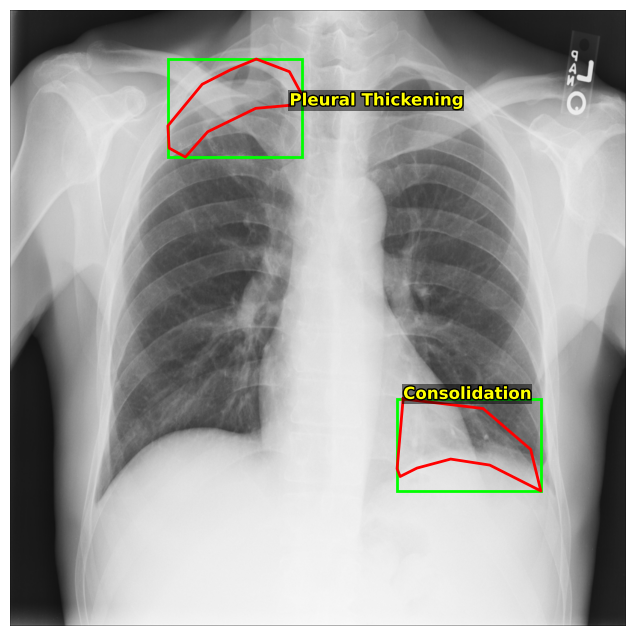

['Pleural Thickening', 'Consolidation']


In [25]:
visualize_item(
    test_data[-5], 
    image_dir='/mnt/workspace/ChestX-Det-Dataset/test', 
    figsize=(8, 8)
)

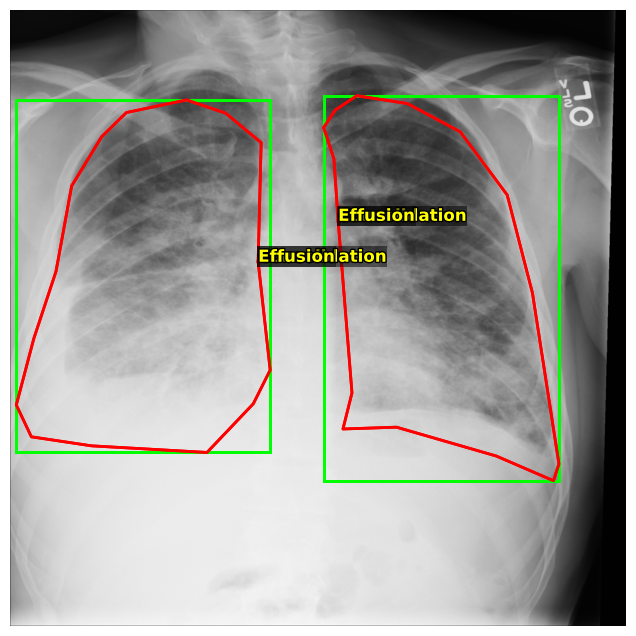

['Consolidation', 'Effusion', 'Consolidation', 'Effusion']


In [26]:
visualize_item(
    test_data[-6], 
    image_dir='/mnt/workspace/ChestX-Det-Dataset/test', 
    figsize=(8, 8)
)

In [95]:
for i in range(len(test_data)):
    if '39430' in test_data[i]['file_name']:
        print(i, test_data[i])

14 {'file_name': '39430.png', 'syms': ['Consolidation', 'Effusion'], 'boxes': [[156, 316, 474, 647], [115, 442, 486, 722]], 'polygons': [[[293, 331], [246, 316], [216, 345], [210, 368], [201, 410], [181, 444], [176, 500], [164, 561], [156, 597], [205, 624], [263, 647], [357, 618], [416, 623], [441, 624], [474, 532], [469, 471], [421, 415], [460, 359], [456, 328], [293, 331]], [[147, 488], [123, 632], [115, 699], [132, 722], [216, 694], [316, 693], [409, 705], [486, 571], [465, 495], [365, 512], [172, 442], [147, 488]]]}


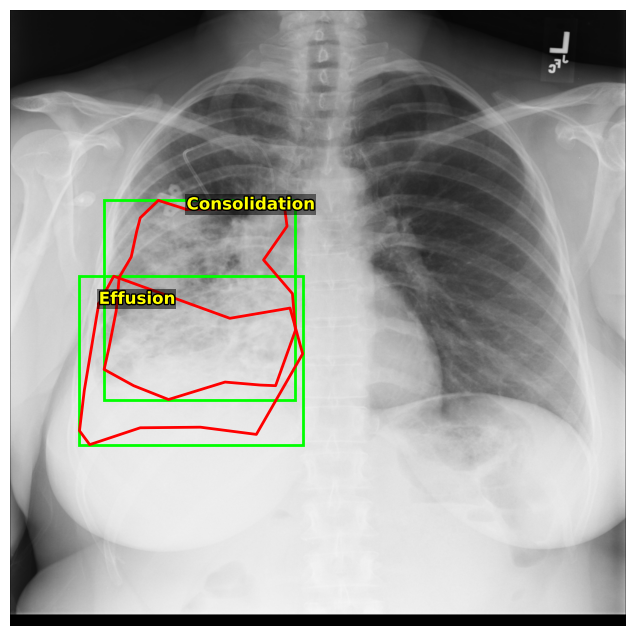

['Consolidation', 'Effusion']


In [96]:
visualize_item(
    test_data[14], 
    image_dir='/mnt/workspace/ChestX-Det-Dataset/test', 
    figsize=(8, 8)
)

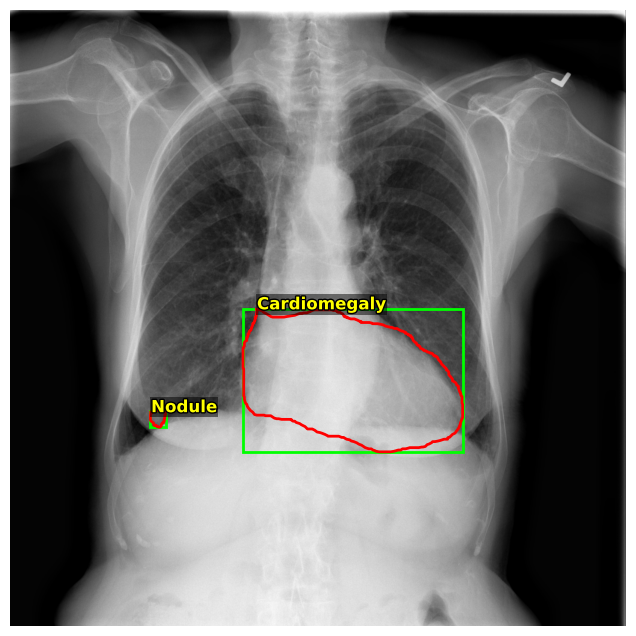

['Cardiomegaly', 'Nodule']


In [31]:
visualize_item(
    train_data[4], 
    image_dir='/mnt/workspace/ChestX-Det-Dataset/train', 
    figsize=(8, 8)
)

In [43]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

def visualize_polygon_mask_on_image(
    image_path, polygon, mask_res, mask_alpha=0.4, grid_color='cyan', poly_color='red', figsize=(8, 8)
):
    """
    Visualize an image, a polygon, and a mask grid overlay.

    Args:
        image_path (str): Path to the image.
        polygon (list of [x, y]): Polygon points.
        mask_res (tuple): (H, W) resolution for the mask.
        mask_alpha (float): Transparency for the mask overlay.
        grid_color (str): Color for the grid overlay.
        poly_color (str): Color for the polygon outline.
        figsize (tuple): Figure size.
    """
    # Load image
    img = cv2.imread(image_path)
    if img is None:
        raise FileNotFoundError(f"Image not found: {image_path}")
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_h, img_w = img.shape[:2]

    # Create mask at mask_res
    mask_h, mask_w = mask_res
    mask = np.zeros((mask_h, mask_w), dtype=np.uint8)
    pts = np.array(polygon, dtype=np.float32)
    # Scale polygon to mask resolution
    scale_x = mask_w / img_w
    scale_y = mask_h / img_h
    pts_scaled = np.stack([pts[:, 0] * scale_x, pts[:, 1] * scale_y], axis=1).astype(np.int32)
    cv2.fillPoly(mask, [pts_scaled.reshape((-1, 1, 2))], color=1)

    # Upscale mask to image size
    mask_up = cv2.resize(mask, (img_w, img_h), interpolation=cv2.INTER_NEAREST)

    # Plot
    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(img)
    ax.imshow(
        np.ma.masked_where(mask_up == 0, mask_up),
        cmap='Blues',
        alpha=mask_alpha,
        interpolation='nearest'
    )

#     # Draw grid lines for the mask cells
#     for y in np.linspace(0, img_h, mask_h + 1):
#         ax.axhline(y, color=grid_color, lw=0.5, alpha=0.5)
#     for x in np.linspace(0, img_w, mask_w + 1):
#         ax.axvline(x, color=grid_color, lw=0.5, alpha=0.5)
        
    # Draw grid lines for the mask cells (within image bounds)
    for y in np.linspace(0, img_h, mask_h + 1):
        ax.plot([0, img_w], [y, y], color=grid_color, lw=0.5, alpha=0.5)
    for x in np.linspace(0, img_w, mask_w + 1):
        ax.plot([x, x], [0, img_h], color=grid_color, lw=0.5, alpha=0.5)

    # Draw polygon
    poly = np.array(polygon)
    ax.plot(
        np.append(poly[:, 0], poly[0, 0]),
        np.append(poly[:, 1], poly[0, 1]),
        color=poly_color,
        linewidth=2
    )

    ax.set_axis_off()
    plt.tight_layout()
    plt.show()

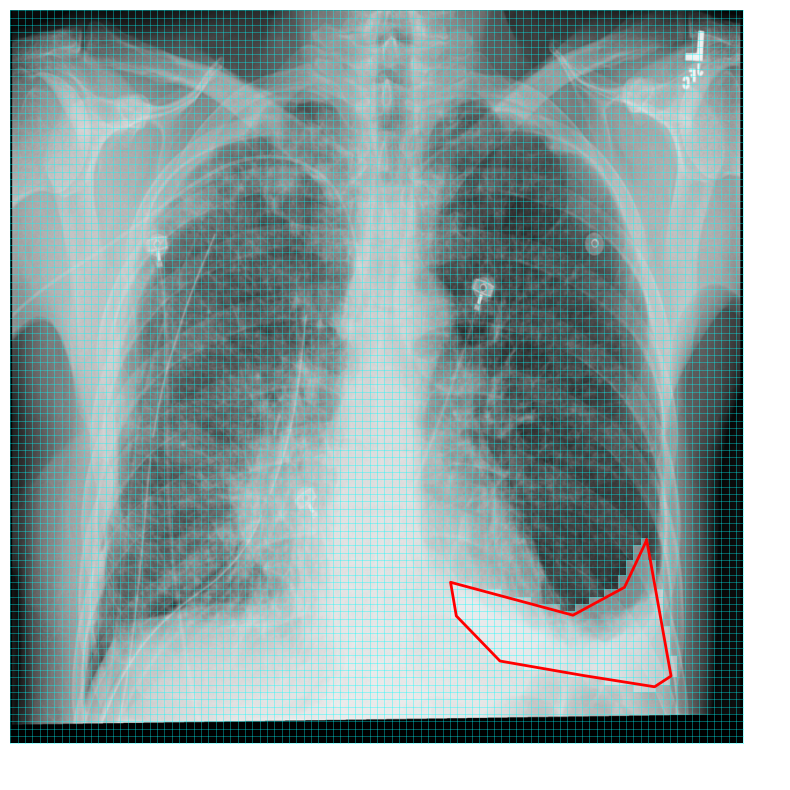

In [44]:
item = test_data[-3]
polygon = item['polygons'][0]
image_path = '/mnt/workspace/ChestX-Det-Dataset/test/' + item['file_name']
visualize_polygon_mask_on_image(image_path, polygon, mask_res=(100, 100), mask_alpha=0.4)

In [11]:
from importlib import reload
import medvqa

In [34]:
reload(medvqa.datasets.chestxdet.chestxdet_phrase_grounding_dataset_management)

<module 'medvqa.datasets.chestxdet.chestxdet_phrase_grounding_dataset_management' from '/home/pamessina/medvqa/medvqa/datasets/chestxdet/chestxdet_phrase_grounding_dataset_management.py'>

In [35]:
from medvqa.datasets.chestxdet.chestxdet_phrase_grounding_dataset_management import ChestXDetInferenceDataset
from medvqa.datasets.image_transforms_factory import create_image_transforms

In [36]:
test_dataset = ChestXDetInferenceDataset(
    json_path='/mnt/workspace/ChestX-Det-Dataset/ChestX_Det_test.json',
    image_dir='/mnt/workspace/ChestX-Det-Dataset/test/',
    image_transform=create_image_transforms(use_model_specific_transforms=False, image_size=(384, 384)),
    mask_res=(100, 100),
    bbox_format='cxcywh',
)

In [78]:
len(test_dataset)

1172

In [97]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
from PIL import Image
import torch

def denormalize_image(tensor, mean, std):
    """
    Denormalize a tensor image using mean and std.
    Args:
        tensor: torch.Tensor of shape (3, H, W)
        mean: tuple of 3 floats
        std: tuple of 3 floats
    Returns:
        np.ndarray of shape (H, W, 3), values in [0, 1]
    """
    if isinstance(tensor, torch.Tensor):
        tensor = tensor.clone().cpu()
        for t, m, s in zip(tensor, mean, std):
            t.mul_(s).add_(m)
        img = tensor.numpy()
        img = np.clip(img, 0, 1)
        img = np.transpose(img, (1, 2, 0))
        return img
    else:
        raise ValueError("Input must be a torch.Tensor")

def visualize_chestxdet_item_multi(
    item,
    mask_alpha=0.4,
    bbox_color='lime',
    poly_color='red',
    mask_cmap='Blues',
    figsize=(8, 8),
    image_mean=(0.485, 0.456, 0.406),
    image_std=(0.229, 0.224, 0.225),
    bbox_format='xyxy',
):
    """
    Visualize a dataset item: image, multiple bboxes, polygons, mask overlay, and label.

    Args:
        item: dict from ChestXDetInferenceDataset __getitem__.
        mask_alpha: transparency for mask overlay.
        bbox_color: color for bbox.
        poly_color: color for polygon.
        mask_cmap: colormap for mask.
        figsize: matplotlib figure size.
        image_mean: mean used for normalization.
        image_std: std used for normalization.
    """
    # Denormalize image
    img = denormalize_image(item['pixel_values'], image_mean, image_std)
    img_h, img_w = img.shape[:2]

    # Resize mask to image size
    mask = item['mask']
    mask_img = np.array(Image.fromarray(mask).resize((img_w, img_h), resample=Image.NEAREST))

    # Plot
    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(img)
    ax.imshow(
        np.ma.masked_where(mask_img == 0, mask_img),
        cmap=mask_cmap,
        alpha=mask_alpha,
        interpolation='nearest'
    )

    # Draw all bboxes and polygons
    for bbox, polygon in zip(item['bboxes'], item['polygons']):
        # Denormalize bbox
        if len(bbox) == 4:
            if bbox_format == 'xyxy':
                x1, y1, x2, y2 = bbox
                x1, x2 = x1 * img_w, x2 * img_w
                y1, y2 = y1 * img_h, y2 * img_h
            elif bbox_format == 'cxcywh':
                cx, cy, w, h = bbox
                cx, w = cx * img_w, w * img_w
                cy, h = cy * img_h, h * img_h
                x1 = cx - w / 2
                x2 = cx + w / 2
                y1 = cy - h / 2
                y2 = cy + h / 2
            else: assert False
        else:
            raise ValueError("bbox must have 4 elements")
        # Draw bbox
        rect = patches.Rectangle(
            (x1, y1), x2 - x1, y2 - y1,
            linewidth=2, edgecolor=bbox_color, facecolor='none'
        )
        ax.add_patch(rect)
        # Denormalize polygon
        poly_pts = np.array([[x * img_w, y * img_h] for x, y in polygon])
        ax.plot(
            np.append(poly_pts[:, 0], poly_pts[0, 0]),
            np.append(poly_pts[:, 1], poly_pts[0, 1]),
            color=poly_color, linewidth=2
        )

    # Draw label (top left corner)
    label = item.get('label', None)
    if label is not None:
        ax.text(
            5, 20, str(label),
            color='white', fontsize=16, weight='bold',
            bbox=dict(facecolor='black', alpha=0.7, pad=2, edgecolor='none')
        )

    ax.set_axis_off()
    plt.tight_layout()
    plt.show()

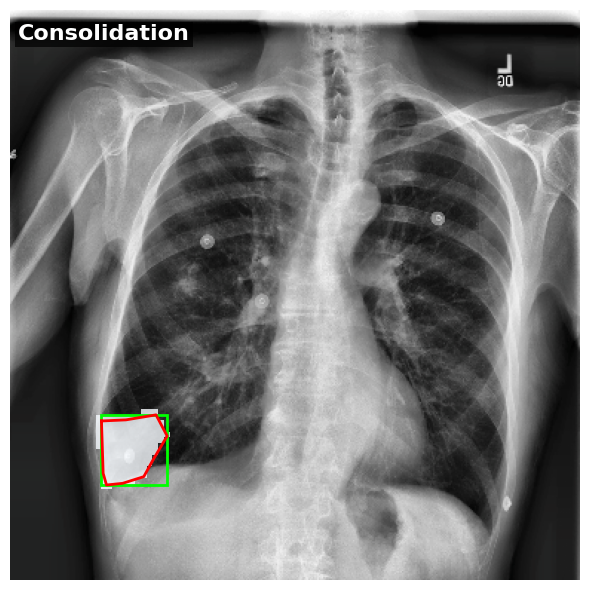

In [106]:
item = test_dataset[43]
visualize_chestxdet_item_multi(item, figsize=(6,6), mask_alpha=0.8, bbox_format='cxcywh')